<a href="https://colab.research.google.com/github/221fa04015/4_2_Project/blob/main/4_2_Projectork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
subhajournal_patient_health_detection_using_vocal_audio_path = kagglehub.dataset_download('subhajournal/patient-health-detection-using-vocal-audio')

print('Data source import complete.')


In [ ]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [ ]:
import os
folder = '/kaggle/input/patient-health-detection-using-vocal-audio/patient-vocal-dataset/patient-vocal-dataset'
classes = os.listdir(folder)
for cla in classes:
    samp = len([i for i in os.listdir(f'{folder}/{cla}') if i.endswith('.wav')])
    print(f'Detected {samp} samples for class: {cla}')

Detected 84 samples for class: Laryngozele
Detected 392 samples for class: Vox senilis
Detected 560 samples for class: Normal


In [ ]:
def extract_features(file_path, n_mfcc=40, max_len=174):
    """Load an audio file and return its normalized MFCCs"""
    y, sr = librosa.load(file_path, sr=None)  # sr=None keeps original sampling rate
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Pad or truncate to make all MFCCs the same size
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

In [ ]:
def load_dataset(folder):
    """Load all audio files and create X (features) and y (labels)"""
    classes = os.listdir(folder)
    X, y = [], []
    class_map = {cla:i for i, cla in enumerate(classes)}  # dictionary: class name -> int label

    for cla in classes:
        class_folder = os.path.join(folder, cla)
        for file in os.listdir(class_folder):
            if file.endswith('.wav'):
                file_path = os.path.join(class_folder, file)
                mfcc = extract_features(file_path)
                X.append(mfcc)
                y.append(class_map[cla])

    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=len(classes))

    # CNN expects 4D input: (samples, height, width, channels)
    X = X[..., np.newaxis]  # add channel dimension
    return X, y, class_map

In [ ]:
# Load the dataset
X, y, class_map = load_dataset(folder)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1036, 40, 174, 1), y shape: (1036, 3)


In [ ]:
from sklearn.model_selection import train_test_split

# First split: train+validation and test (20% for test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: train and validation (20% of the temp -> 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (662, 40, 174, 1), Validation shape: (166, 40, 174, 1), Test shape: (208, 40, 174, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentations
datagen = ImageDataGenerator(
    width_shift_range=0.1,   # shift along time axis
    height_shift_range=0.1,  # shift along MFCC coefficients
    zoom_range=0.1,          # slight zoom in/out
    horizontal_flip=False,   # flipping MFCCs horizontally is usually not meaningful
    vertical_flip=False,     # flipping vertically may distort MFCC patterns
)

In [ ]:
def augment_minority_classes(X_train, y_train):
    """Augment only the minority classes to balance the dataset"""
    X_aug, y_aug = [], []
    y_int = np.argmax(y_train, axis=1)
    class_counts = np.bincount(y_int)
    max_count = class_counts.max()

    for c in range(len(class_counts)):
        X_c = X_train[y_int == c]
        y_c = y_train[y_int == c]
        n_samples = len(X_c)
        n_to_generate = max_count - n_samples

        X_aug.append(X_c)
        y_aug.append(y_c)

        if n_to_generate > 0:
            # Generate augmented samples
            i = 0
            while i < n_to_generate:
                for x in X_c:
                    x_aug = datagen.random_transform(x)
                    X_aug.append(np.expand_dims(x_aug, axis=0))
                    y_aug.append(np.expand_dims(y_c[0], axis=0))
                    i += 1
                    if i >= n_to_generate:
                        break

    # Concatenate everything
    X_aug = np.concatenate(X_aug)
    y_aug = np.concatenate(y_aug)
    return X_aug, y_aug

X_train_bal, y_train_bal = augment_minority_classes(X_train, y_train)
print(f"Balanced train shape after augmentation: {X_train_bal.shape}, {y_train_bal.shape}")

Balanced train shape after augmentation: (1074, 40, 174, 1), (1074, 3)


In [ ]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

7/7 - 0s - 36ms/step - accuracy: 0.7212 - loss: 1.1868
Test Accuracy: 0.7212, Test Loss: 1.1868


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


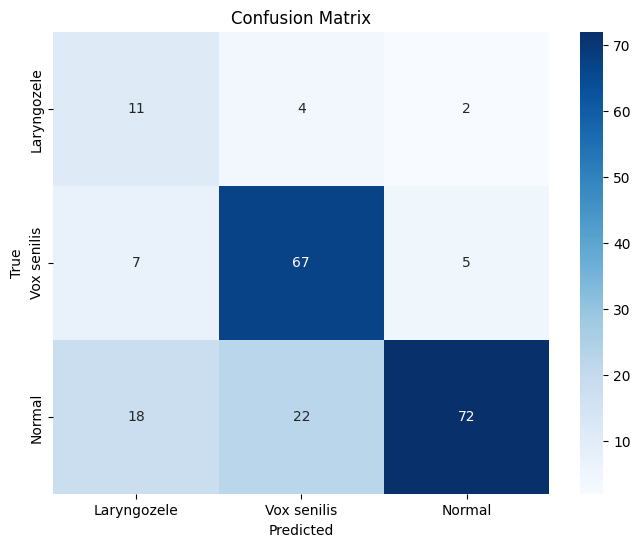

              precision    recall  f1-score   support

 Laryngozele       0.31      0.65      0.42        17
 Vox senilis       0.72      0.85      0.78        79
      Normal       0.91      0.64      0.75       112

    accuracy                           0.72       208
   macro avg       0.65      0.71      0.65       208
weighted avg       0.79      0.72      0.74       208



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict classes for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_map.keys(), yticklabels=class_map.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Optional: detailed classification report
print(classification_report(y_true, y_pred_classes, target_names=class_map.keys()))

### ***wav2vec***

In [ ]:
pip install transformers torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2Model

In [ ]:
# Use a pre-trained English wav2vec2 base model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/facebook/wav2vec2-base-960h/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


OSError: Can't load processor for 'facebook/wav2vec2-base-960h'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'facebook/wav2vec2-base-960h' is the correct path to a directory containing a processor_config.json file

In [ ]:
import torchaudio
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model

def extract_wav2vec_embeddings(file_path):
    # Load audio
    waveform, sr = torchaudio.load(file_path)  # waveform shape: (channels, samples)
    waveform = waveform.squeeze()  # remove channel dimension if mono

    # Resample to 16kHz if needed
    target_sr = 16000
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr

    # Convert to numpy for processor
    speech_array = waveform.numpy()

    # Preprocess
    inputs = processor(speech_array, sampling_rate=sr, return_tensors="pt", padding=True)

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)

    # Take mean over time dimension to get fixed-size embedding
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    return embeddings

In [ ]:
X, y = [], []
classes = os.listdir(folder)
class_map = {cla:i for i, cla in enumerate(classes)}
for cla in classes:
    class_folder = os.path.join(folder, cla)
    for file in os.listdir(class_folder):
        if file.endswith('.wav'):
            file_path = os.path.join(class_folder, file)
            emb = extract_wav2vec_embeddings(file_path)
            X.append(emb)
            y.append(class_map[cla])
X = np.array(X)
y = to_categorical(np.array(y), num_classes=len(classes))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X, y, epochs=200, batch_size=32, validation_split=0.2)